<h1 align="center"> Baseline Models - Embeddings </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
# Additional imports needed to load src.model and src.dataset
import sys
sys.path.append("..")

import os
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
import torch
import pandas as pd
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from src.model import CLIPModel, RNAEncoder, ImageEncoder, ContrastiveLoss
from src.dataset import RNACustomDataset, ImgCustomDataset
from sklearn.model_selection import train_test_split
import torch.nn as nn 
import numpy as np
import albumentations as albu # For image augmentations
import cv2
from albumentations.pytorch import ToTensorV2
from src.optimise import set_seed, calc_mean_std, generate_model_name, capitalize_j, format_case_id
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import spearmanr
np.random.seed(2)

# Set random seed for weights
random_seed = 2
set_seed(random_seed)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
import sklearn.metrics as mx

Random seed set as 2


<i> Helper Functions: <i>

In [2]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

def modelPerformance(confMat):
    TN = confMat[0, 0]
    TP = confMat[1, 1]
    FP = confMat[0, 1]
    FN = confMat[1, 0]
    prec = TP / (TP + FP)
    rec = TP / (TP + FN)
    spec = TN / (TN + FP)
    fpr = FP / (TN + FP)
    f1 = 2 * (prec * rec) / (prec + rec)
    acc = (TP + TN) / (TP + FP + TN + FN)
    return (acc, prec, rec, spec, fpr, f1)

def printPerformance(confMat):
    acc, prec, rec, spec, fpr, f1 = modelPerformance(confMat)
    print("Accuracy = " "%.4f" % acc)
    print("Precision = " "%.4f" % prec)
    print("Recall = " "%.4f" % rec)
    print("Specificity = " "%.4f" % spec)
    print("False positive rate = " "%.4f" % fpr)
    print("F1-score = " "%.4f" % f1)
    np.set_printoptions(precision=2)
    print("Confusion matrix (%):")
    print(confMat/np.sum(confMat)*100)

def proximityMatrix(mdl, X, normalize=True):      
    endNode = mdl.apply(X)
    nTrees = endNode.shape[1]
    n = X.shape[0]
    proxMat = np.zeros((n,n))
    for k in range(0, nTrees):
        a = endNode[:,k]
        proxMat += 1*np.equal.outer(a, a)
    if normalize:
        proxMat = proxMat / nTrees
    return proxMat

### Matching Samples for Analysis

In [3]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

### Filter Images and RNA Data

In [4]:
# Step 1: Prepare image filenames and filter RNA data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
rna_data_filtered = []
surgical = []
sample_count = 0 

paired_id_list = []

In [5]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

            # Check if either case_id or case_id2 is a substring of the filename
            # Only check if the ID is non-empty
            if (case_id and case_id in file_name_corrected):
                image_filenames.append(file_name)
                rna_data_filtered.append(
                    row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                surgical.append(row["SURGICAL"])
                paired_id_list.append(case_id)
                sample_count += 1
                break

            if (case_id2 and case_id2 in file_name_corrected):
                image_filenames.append(file_name)
                rna_data_filtered.append(
                    row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                surgical.append(row["SURGICAL"])
                paired_id_list.append(case_id2)
                sample_count += 1
                break

print(f"Number of Samples: ", sample_count)

Number of Samples:  29


In [6]:
# Step 11: Obtain unpaired data for validation
unpaired_image_filenames = []
surgical_unpaired = []
number_unpaired_images = 0 

In [7]:
for index, row in df_merged_copy.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    unpaired_image_filenames.append(file_name)
                    surgical_unpaired.append(row["SURGICAL"])
                    number_unpaired_images += 1
                    break  # Only use the first matching image for each row

print(f"Number of Unpaired Image Samples: ", number_unpaired_images)

Number of Unpaired Image Samples:  32


In [8]:
set(unpaired_image_filenames) & set(image_filenames)

{'12930_3.nii.gz',
 '13291_0010.nii.gz',
 '14023_3.nii.gz',
 '14024_2.nii.gz',
 '14056_3.nii.gz',
 '14654_3.nii.gz',
 '14984_0039.nii.gz',
 '16106_0022.nii.gz',
 '16134_0049.nii.gz',
 '16208_1.nii.gz',
 '16439_0004.nii.gz',
 '18638_0037.nii.gz',
 '187867.nii.gz',
 '18852_0009.nii.gz',
 '18853_0020.nii.gz',
 '24354_0019.nii.gz',
 '24903_0011.nii.gz',
 '25607_0005.nii.gz',
 '25827_0006.nii.gz',
 '25961_2.nii.gz',
 '25962_0006.nii.gz',
 '25970_2.nii.gz',
 '26379_5.nii.gz',
 '26417_1.nii.gz',
 '26424_0007.nii.gz',
 '26425_-3.nii.gz',
 '26428_0020.nii.gz',
 '26604_0007.nii.gz',
 'J630_0008.nii.gz'}

In [9]:
df_unpaired_rna = df_merged_copy[~df_merged_copy["CASE ID"].isin(paired_id_list) & ~df_merged_copy["CASE ID2"].isin(paired_id_list)]

print("Number of rows in unpaired RNA samples:", df_unpaired_rna.shape[0])

Number of rows in unpaired RNA samples: 38


In [10]:
check1 = df_unpaired_rna["CASE ID"].to_list() + df_unpaired_rna["CASE ID2"].to_list()
check2 = paired_id_list
set(check1) & set(check2)

set()

### Train-test Split

In [11]:
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [12]:
# Step 1: Split into train and test sets
rna_train, rna_test, img_train, img_test, surg_train, surg_test = train_test_split(rna_data_filtered, image_filenames, surgical, test_size=0.2, random_state=2)

In [13]:
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [14]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [15]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


## Scale and Transform the Data

In [16]:
# Scale RNA sample counts
scaler = StandardScaler()
rna_train = pd.DataFrame(scaler.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(scaler.transform(rna_test), columns=rna_data_filtered.columns)

In [17]:
rna_train

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,0.391489,2.095373,0.845661,0.0,-0.706518,-0.213201,0.0,-0.273434,0.0,-0.277051,...,0.982061,-0.458831,-0.213201,-0.458831,-0.249747,-0.598463,-0.098433,0.593454,0.0,0.405475
1,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,0.411754,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
2,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,-1.291525,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
3,1.391962,-0.570655,-0.179775,0.0,0.022526,-0.213201,0.0,-0.273434,0.0,0.429047,...,-0.439767,-0.458831,-0.213201,2.179449,-0.197033,-0.315460,0.153118,-0.379423,0.0,-0.643496
4,0.391489,-0.144721,2.499588,0.0,0.092840,-0.213201,0.0,1.298813,0.0,-0.297225,...,0.925221,-0.458831,-0.213201,-0.458831,-0.159288,0.478861,-0.098433,0.594507,0.0,0.026723
5,-0.608984,-0.539104,-1.117001,0.0,-1.117300,-0.213201,0.0,4.443309,0.0,-0.089719,...,0.503722,-0.458831,-0.213201,2.179449,-0.517806,-0.230226,-1.607734,0.483332,0.0,1.357289
6,1.892199,-0.428677,0.139985,0.0,0.126147,-0.213201,0.0,-0.273434,0.0,0.097613,...,-0.830967,2.179449,-0.213201,-0.458831,-0.740485,-0.584550,-0.601533,-0.532274,0.0,-0.567642
7,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,-0.660361,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
8,-0.608984,-0.255148,-0.764163,0.0,0.118745,-0.213201,0.0,-0.273434,0.0,1.048683,...,-0.076327,-0.458831,-0.213201,-0.458831,-0.470768,1.787090,1.913969,-0.312919,0.0,-0.664278
9,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,-0.611366,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500


In [18]:
#### Calculate mean and standard deviation for normalisation ####

# Define pre-transforms 
pre_transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=(0, 0, 0), std=(1, 1, 1)),
    ToTensorV2()
])

# Create dataset with image_directory passed in
train_img_dataset = ImgCustomDataset(img_train, image_directory, transform=pre_transform_albu, transform_type="albu")

# Calculate mean and standard deviation 
num_imgs = len(img_train)
calc_mean, calc_std = calc_mean_std(train_img_dataset, num_imgs)

print(f"Mean: {calc_mean}")
print(f"Standard Deviation: {calc_std}")

#### END ####

Mean: [0.13462063670158386, 0.13462063670158386, 0.13462063670158386]
Standard Deviation: [0.19484363496303558, 0.19484363496303558, 0.19484363496303558]


In [19]:
# Define transforms 
transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=calc_mean, std=calc_std),
    ToTensorV2()
])

### Load Data

In [20]:
# Create dataset with image_directory passed in
train_dataset = RNACustomDataset(rna_train, img_train, image_directory, transform=transform_albu, transform_type="albu")
test_dataset = RNACustomDataset(rna_test, img_test, image_directory, transform=transform_albu, transform_type="albu")

In [21]:
batch_size = 23
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

batch_size = 6
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

### Load Encoders

In [22]:
model_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/saved_models/"
model_name = "icy-mackerel-469.pt"
model_path = model_directory + model_name

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: ", device)

rna_encoder = RNAEncoder(input_dim=len(rna_cols.columns), embedding_dim=128)
image_encoder = ImageEncoder(embedding_dim=128)

model = CLIPModel(rna_encoder, image_encoder).to(device)

Device:  cuda


In [24]:
checkpoint = torch.load(model_path)
rna_encoder.load_state_dict(checkpoint["rna_encoder_state_dict"])
image_encoder.load_state_dict(checkpoint["image_encoder_state_dict"])
model.load_state_dict(checkpoint["clip_model_state_dict"])

/tmp/ipykernel_90695/1083309617.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


<All keys matched successfully>

In [25]:
rna_encoder.eval()
image_encoder.eval()
model.eval()

CLIPModel(
  (rna_encoder): RNAEncoder(
    (model): Sequential(
      (0): Linear(in_features=63187, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): ReLU()
      (5): Linear(in_features=512, out_features=512, bias=True)
      (6): ReLU()
      (7): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (image_encoder): ImageEncoder(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): Bat

### Create Embedding Master DataFrames

In [26]:
with torch.no_grad():
    for rna_batch, image_batch, labels in train_loader:
        rna_batch, image_batch, labels = rna_batch.to(device), image_batch.to(device), labels.to(device)
        # Forward pass through both encoders
        rna_embeddings_train, image_embeddings_train = model(rna_batch, image_batch)

In [27]:
rna_embeddings_train.size()

torch.Size([23, 128])

In [28]:
image_embeddings_train.size()

torch.Size([23, 128])

In [29]:
with torch.no_grad():
    for rna_batch, image_batch, labels in test_loader:
        rna_batch, image_batch, labels = rna_batch.to(device), image_batch.to(device), labels.to(device)
        # Forward pass through both encoders
        rna_embeddings_test, image_embeddings_test = model(rna_batch, image_batch)

In [30]:
rna_embeddings_test.size()

torch.Size([6, 128])

In [31]:
image_embeddings_test.size()

torch.Size([6, 128])

In [32]:
# Scaler for embeddings 
scaler = StandardScaler()

In [33]:
# RNA DataFrame
rna_df_train = pd.DataFrame(scaler.fit_transform(rna_embeddings_train.cpu().numpy()))
rna_df_train.insert(0, "SURGICAL", surg_train)

In [34]:
rna_df_train

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,M-S,-0.691423,-0.501440,-0.506153,-0.279883,-0.263591,0.356139,-0.620558,-1.345524,0.604003,...,1.460281,0.245303,1.097973,-0.396734,-0.189886,0.420095,0.412014,-0.370940,-0.638268,0.431748
1,M-S,0.172900,0.025384,0.083831,0.311965,-0.237960,-0.879859,0.105620,-0.407074,-0.204512,...,-0.347746,-0.343440,-0.331828,0.250645,0.093024,-0.028220,-0.129533,-0.083851,0.017091,-0.322649
2,M-S,0.172900,0.025384,0.083831,0.311965,-0.237960,-0.879859,0.105620,-0.407074,-0.204512,...,-0.347746,-0.343440,-0.331828,0.250645,0.093024,-0.028220,-0.129533,-0.083851,0.017091,-0.322649
3,M-S,2.007104,2.054878,1.893779,2.013385,1.697999,-1.159139,1.980753,1.744126,-1.998202,...,-2.206294,1.952477,-1.866908,1.722076,1.806726,-2.032343,-2.034984,1.862266,1.930186,-1.584260
4,M-S,0.172900,0.025384,0.083831,0.311965,-0.237960,-0.879859,0.105620,-0.407074,-0.204512,...,-0.347746,-0.343440,-0.331828,0.250645,0.093024,-0.028220,-0.129533,-0.083851,0.017091,-0.322649
5,M-S,0.172900,0.025384,0.083831,0.311965,-0.237960,-0.879859,0.105620,-0.407074,-0.204512,...,-0.347746,-0.343440,-0.331828,0.250645,0.093024,-0.028220,-0.129533,-0.083851,0.017091,-0.322649
6,M-S,-0.954820,-0.323576,-1.280612,-0.965703,-0.414464,0.689900,-0.920911,-1.446609,0.999439,...,1.176538,-1.543870,0.540231,-0.686976,-0.947819,0.685143,1.204069,-0.674911,-0.918388,0.873179
7,M-S,0.015817,0.291462,0.358332,-0.184789,0.492876,-0.982997,0.525122,0.765165,-0.302678,...,-0.227381,0.679367,-0.268249,0.511731,0.628678,-0.290349,-0.126498,0.399377,0.289231,-0.152994
8,B-S,-1.258932,-1.510920,-1.555347,-1.449364,-1.564850,-0.078073,-0.949924,-2.061385,0.839129,...,0.216749,-0.631650,0.954666,-1.313530,-0.738505,1.133990,1.244632,-1.536184,-0.913630,1.622610
9,M-S,0.292966,0.335727,0.352374,0.365308,0.723857,1.267166,0.327008,0.611638,-0.171869,...,0.413098,0.767232,-0.267966,0.167321,0.109565,-0.408053,0.116746,-0.026373,0.415456,-0.433303


In [35]:
# RNA DataFrame
rna_df_test = pd.DataFrame(scaler.fit_transform(rna_embeddings_test.cpu().numpy()))
rna_df_test.insert(0, "SURGICAL", surg_test)

In [36]:
rna_df_test

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,M-S,-0.416587,-0.365934,-0.454438,-0.272119,-1.089807,0.625027,-0.486522,-0.445962,0.340625,...,-0.427717,-0.464494,0.863754,-0.241276,-0.575203,0.372909,0.499529,-0.462021,-0.474543,0.466370
1,B-S,1.400624,1.358400,1.374307,1.305776,1.346395,-1.294433,1.363952,1.386757,-1.302760,...,-1.071667,0.914843,-1.348111,1.385246,1.225685,-1.266816,-1.303507,1.287609,1.410799,-1.538018
2,B-S,-1.504693,-1.690011,-1.512112,-1.598243,-0.534771,1.499977,-1.640478,0.054531,1.742920,...,0.900931,-1.771319,1.083364,-1.843130,-1.555237,1.689960,1.556413,-1.636709,-1.578530,1.633689
3,B-S,-0.416587,-0.365934,-0.454438,-0.272119,-1.089807,0.625027,-0.486522,-0.445962,0.340625,...,-0.427717,-0.464494,0.863754,-0.241276,-0.575203,0.372909,0.499529,-0.462021,-0.474543,0.466370
4,M-S,-0.234175,0.049398,-0.133927,-0.369822,0.140771,-0.385884,0.313060,-1.602324,-0.111141,...,1.767568,0.897102,-0.258652,0.219891,0.338679,-0.046962,-0.080233,0.175119,0.087310,-0.484673
5,M-S,1.171419,1.014080,1.180608,1.206525,1.227219,-1.069714,0.936511,1.052961,-1.010269,...,-0.741399,0.888362,-1.204109,0.720545,1.141278,-1.122000,-1.171731,1.098022,1.029507,-0.543737


In [37]:
# Image DataFrame
image_df_train = pd.DataFrame(scaler.fit_transform(image_embeddings_train.cpu().numpy()))
image_df_train.insert(0, "SURGICAL", surg_train)

In [38]:
image_df_train

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,M-S,1.058382,1.320604,0.504909,0.727313,0.276794,-1.242136,0.777106,-0.250038,-0.691461,...,-0.670198,-0.917054,-0.544313,0.656619,0.696289,-0.835509,-0.852357,0.638131,0.710994,-0.506533
1,M-S,-0.219284,-0.436217,0.865217,-0.601463,-0.806996,-0.286626,-0.124714,-1.407417,0.000949,...,0.875341,0.104177,0.419738,-0.407451,-0.383197,0.248457,-0.099262,-0.541518,-0.127815,-0.015436
2,M-S,-0.408087,0.141981,-0.168009,0.481975,0.553697,-0.101441,0.152227,0.643988,0.033649,...,-0.875174,0.766156,-0.713958,-0.326960,0.189138,0.519745,-0.168541,0.225778,-0.201742,0.699422
3,M-S,0.383557,0.204179,-0.566755,-0.092000,0.087094,-0.811108,-0.130256,1.463838,0.324114,...,-1.128837,-0.608268,0.112993,-0.470365,0.199177,0.250702,-0.003760,0.236429,-0.272141,-0.270525
4,M-S,-1.138709,-1.368477,-1.092454,-1.203324,-1.874202,1.628209,-1.212105,-1.515757,1.383596,...,1.376580,0.655855,0.708862,-1.258231,-1.473528,1.112000,0.982008,-1.727370,-1.440629,0.268831
5,M-S,-0.219284,-0.436217,0.865217,-0.601463,-0.806996,-0.286626,-0.124714,-1.407417,0.000949,...,0.875341,0.104177,0.419738,-0.407451,-0.383197,0.248457,-0.099262,-0.541518,-0.127815,-0.015436
6,M-S,1.285892,0.887272,1.438332,0.884013,1.829455,-0.943096,1.350670,1.161349,-1.582193,...,-1.061819,1.631057,-1.535427,1.451315,1.194189,-1.499439,-1.216329,1.298777,1.314632,-1.286167
7,M-S,-0.408087,0.141981,-0.168009,0.481975,0.553697,-0.101441,0.152227,0.643988,0.033649,...,-0.875174,0.766156,-0.713958,-0.326960,0.189138,0.519745,-0.168541,0.225778,-0.201742,0.699422
8,B-S,-0.237169,-0.536650,-1.018149,-0.456803,-0.808556,1.185100,-0.792667,1.175089,0.812735,...,1.605812,-1.418917,0.863071,0.385658,-0.822796,0.729168,0.816506,-0.211564,-0.365702,1.451561
9,M-S,-0.083573,0.738489,0.696258,0.728956,1.078702,-0.116719,0.726798,-0.938904,-0.651286,...,-0.286154,0.261824,-0.059923,0.256788,0.780165,-0.500558,0.220336,-0.416024,0.447393,-0.376060


In [39]:
# Image DataFrame
image_df_test = pd.DataFrame(scaler.fit_transform(image_embeddings_test.cpu().numpy()))
image_df_test.insert(0, "SURGICAL", surg_test)

In [40]:
image_df_test

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,M-S,1.175791,0.982890,1.279054,0.924264,1.057787,-1.214630,1.246702,1.212679,-1.163861,...,-0.571435,0.440312,-1.184802,1.193864,1.027077,-0.957521,-1.315817,1.257265,1.091559,-1.396544
1,B-S,-1.537972,-1.527788,-1.544251,-2.067688,-1.102252,0.650246,-1.623524,-1.222979,1.463023,...,-1.300577,-1.280427,0.462620,-1.692117,-1.182653,1.849677,1.332852,-0.704323,-1.888456,0.540024
2,B-S,0.386581,0.909077,-0.316396,0.063917,0.874644,-0.430573,-0.242295,-1.249808,-0.486873,...,-0.239172,-1.483205,-0.449472,0.056602,0.931080,-0.682283,0.069173,0.309546,0.022306,0.473403
3,B-S,-0.600095,-0.673535,-0.348731,0.077621,-0.943983,1.104793,-0.313792,0.023714,0.675786,...,1.341309,0.941504,1.178228,-0.376107,-0.901290,0.373824,0.614805,-1.059877,-0.158484,0.889830
4,M-S,1.175791,0.982890,1.279054,0.924264,1.057787,-1.214630,1.246702,1.212679,-1.163861,...,-0.571435,0.440312,-1.184802,1.193864,1.027077,-0.957521,-1.315817,1.257265,1.091559,-1.396544
5,M-S,-0.600095,-0.673535,-0.348731,0.077621,-0.943983,1.104793,-0.313792,0.023714,0.675786,...,1.341309,0.941504,1.178228,-0.376107,-0.901290,0.373824,0.614805,-1.059877,-0.158484,0.889830


## Image Embeddings

### Fit Random Forest Model

In [41]:
# Seperating out the features
X_train_img = image_df_train.drop(["SURGICAL"], axis=1)
# Seperating out the target
y_train_img = image_df_train[["SURGICAL"]]

In [42]:
# Set the random state for reproducibility
fit_rf_img = RandomForestClassifier(n_estimators=1000, 
                                    class_weight="balanced", 
                                    random_state=2)

In [43]:
# Hyperparameter optimisation
param_dist = { "bootstrap": [True, False],
    "criterion": ["gini", "entropy"], 
    "max_features": ["sqrt", "log2", 0.5, 0.7, None]}

cv_rf_img = GridSearchCV(fit_rf_img, cv=3, param_grid=param_dist, verbose=3)

In [44]:
cv_rf_img.fit(X_train_img, y_train_img.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_img.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.875 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.750 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.875 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.750 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.875 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.750 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.7;, score=0.875 to

In [45]:
# Set best parameters given by grid search
fit_rf_img.set_params(criterion = "gini",
                     max_features = "sqrt")

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=2)

### Out of Bag Error Rate

In [46]:
fit_rf_img.set_params(n_estimators=100,
                        warm_start=True, 
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_img.set_params(n_estimators=i)
    fit_rf_img.fit(X_train_img, y_train_img.values.ravel())

    oob_error = 1 - fit_rf_img.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency

min_oob_error =  0.17391304347826086
min_index =  10


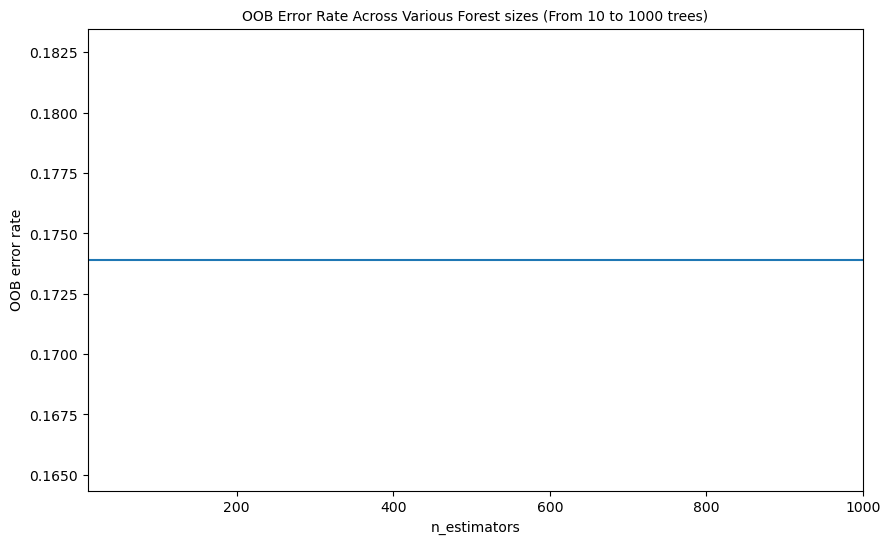

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

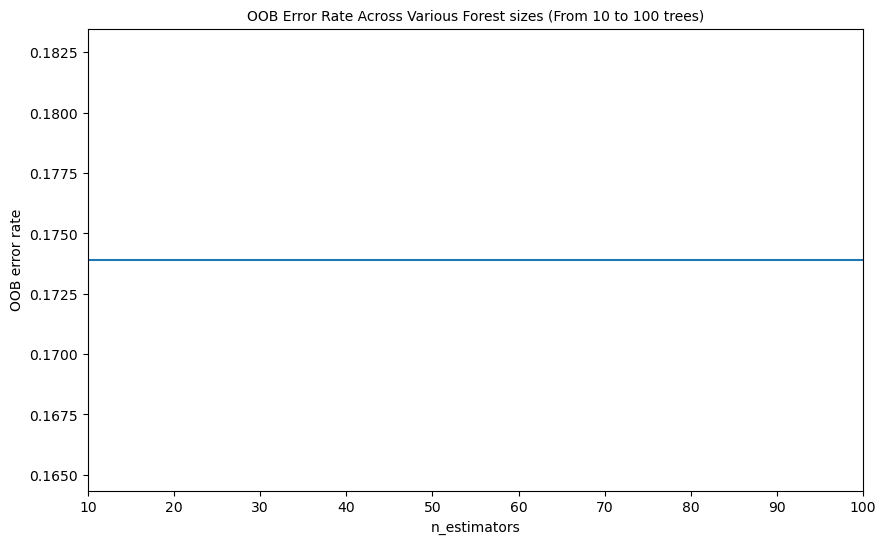

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, 100)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

### Build Random Forest Model Using Best Parameters

In [49]:
# Create the classifier
fit_rf_img.set_params(n_estimators=100, 
                      bootstrap=True, 
                      warm_start=False,
                      criterion= "gini",
                      max_features= "sqrt",
                      oob_score=True,
                      class_weight= "balanced", 
                      random_state=2)

RandomForestClassifier(class_weight='balanced', oob_score=True, random_state=2)

In [50]:
# Fit the model to the training set
fit_rf_img.fit(X_train_img, y_train_img)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', oob_score=True, random_state=2)

### Evaluate Model

#### Train

In [51]:
# Train 
y_train_img_pred = cross_val_predict(fit_rf_img, X_train_img, y_train_img, cv=3)
cmat = mx.confusion_matrix(y_train_img, y_train_img_pred)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [52]:
printPerformance(cmat)

Accuracy = 0.8261
Precision = 0.8636
Recall = 0.9500
Specificity = 0.0000
False positive rate = 1.0000
F1-score = 0.9048
Confusion matrix (%):
[[ 0.   13.04]
 [ 4.35 82.61]]


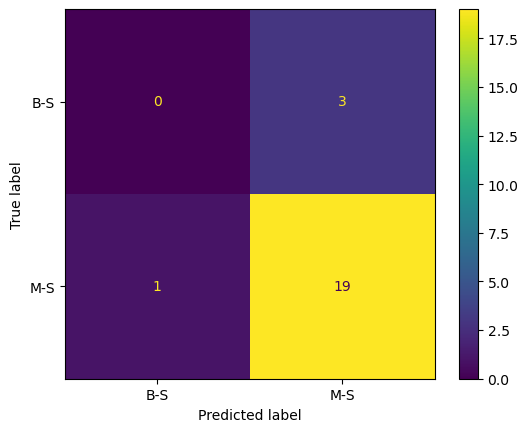

In [53]:
cm = confusion_matrix(y_train_img, y_train_img_pred, labels=fit_rf_img.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_img.classes_)
disp.plot()

#### Test

In [54]:
# Test

# Seperating out the features
X_test_img = image_df_test.drop(["SURGICAL"], axis=1)
# Seperating out the target
y_test_img = image_df_test[["SURGICAL"]]

y_test_img_pred = fit_rf_img.predict(X_test_img)
cmat = mx.confusion_matrix(y_test_img, y_test_img_pred)

In [55]:
printPerformance(cmat)

Accuracy = 0.5000
Precision = 0.5000
Recall = 1.0000
Specificity = 0.0000
False positive rate = 1.0000
F1-score = 0.6667
Confusion matrix (%):
[[ 0. 50.]
 [ 0. 50.]]


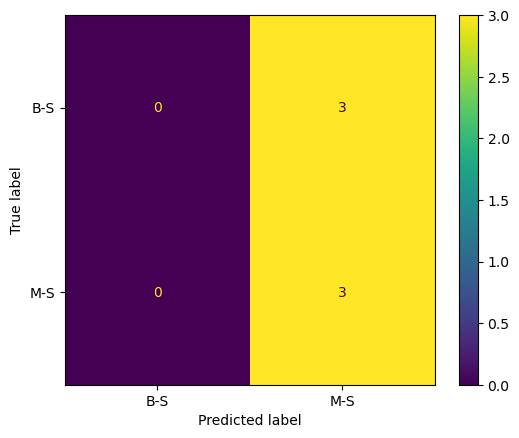

In [56]:
cm = confusion_matrix(y_test_img, y_test_img_pred, labels=fit_rf_img.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_img.classes_)
disp.plot()

### Plot the ROC Curve

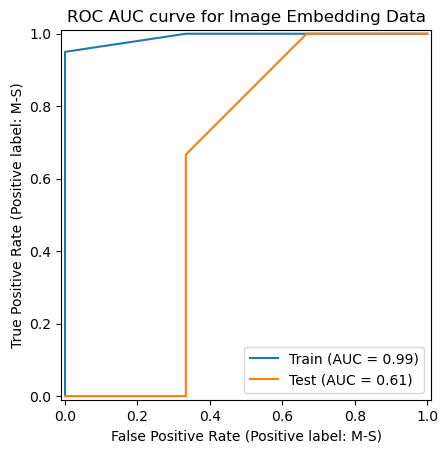

In [57]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_img, X_train_img, y_train_img, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_img, X_test_img, y_test_img, pos_label='M-S', ax = disp.ax_, name="Test")

# # Validation data
# disp = RocCurveDisplay.from_estimator(fit_rf_img, X_val_img, y_val_img, pos_label='M-S', ax = disp.ax_, name="Validation")

disp.ax_.set_title("ROC AUC curve for Image Embedding Data");

## RNA-seq Embeddings

### Fit Random Forest Model

In [58]:
# Seperating out the features
X_train_rna = rna_df_train.drop(["SURGICAL"], axis=1)
# Seperating out the target
y_train_rna = rna_df_train[["SURGICAL"]]

In [59]:
# Set the random state for reproducibility
fit_rf_rna = RandomForestClassifier(n_estimators=1000, 
                                    class_weight="balanced", 
                                    random_state=2)

In [60]:
# Hyperparameter optimisation
param_dist = { "bootstrap": [True, False],
    "criterion": ["gini", "entropy"], 
    "max_features": ["sqrt", "log2", 0.5, 0.7, None]}

cv_rf_rna = GridSearchCV(fit_rf_rna, cv=3, param_grid=param_dist, verbose=3)

In [61]:
cv_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rna.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=1.000 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.875 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=1.000 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=log2;, score=1.000 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.875 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=log2;, score=1.000 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=1.000 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.875 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=1.000 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.7;, score=1.000 to

In [62]:
# Set best parameters given by grid search
fit_rf_rna.set_params(criterion = "gini",
                     max_features = "sqrt")

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=2)

### Out of Bag Error Rate

In [63]:
fit_rf_rna.set_params(n_estimators=100,
                        warm_start=True, 
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rna.set_params(n_estimators=i)
    fit_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())

    oob_error = 1 - fit_rf_rna.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency

min_oob_error =  0.04347826086956519
min_index =  58


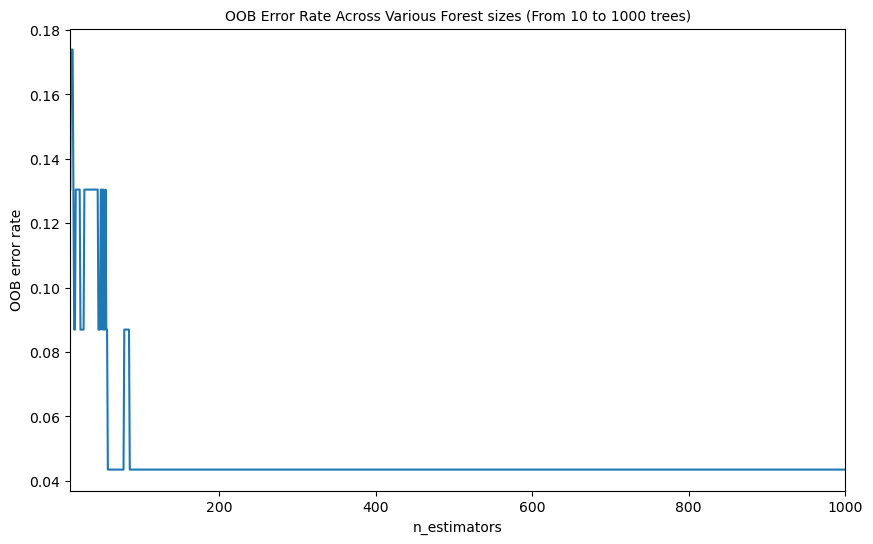

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

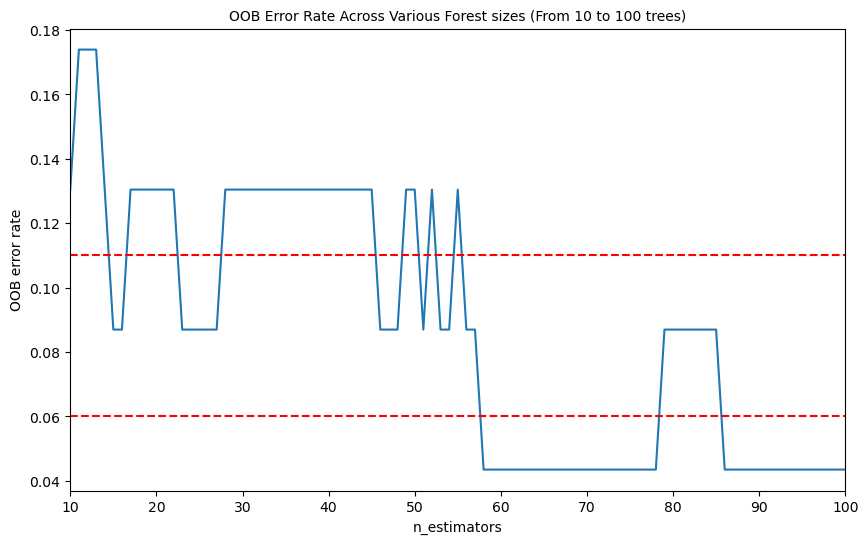

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, 100)
plt.plot(num_estimators, oob_error)
plt.axhline(0.06, color="red", linestyle="--")
plt.axhline(0.11, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

### Build Random Forest Model Using Best Parameters

In [66]:
# Create the classifier
fit_rf_rna.set_params(n_estimators=80, 
                      bootstrap=True, 
                      warm_start=False,
                      criterion= "gini",
                      max_features= "sqrt",
                      oob_score=True,
                      class_weight= "balanced", 
                      random_state=2)

RandomForestClassifier(class_weight='balanced', n_estimators=80, oob_score=True,
                       random_state=2)

In [67]:
# Fit the model to the training set
fit_rf_rna.fit(X_train_rna, y_train_rna)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', n_estimators=80, oob_score=True,
                       random_state=2)

### Evaluate Model

#### Train

In [68]:
# Train 
y_train_rna_pred = cross_val_predict(fit_rf_rna, X_train_rna, y_train_rna, cv=3)
cmat = mx.confusion_matrix(y_train_rna, y_train_rna_pred)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [69]:
printPerformance(cmat)

Accuracy = 0.9565
Precision = 1.0000
Recall = 0.9500
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 0.9744
Confusion matrix (%):
[[13.04  0.  ]
 [ 4.35 82.61]]


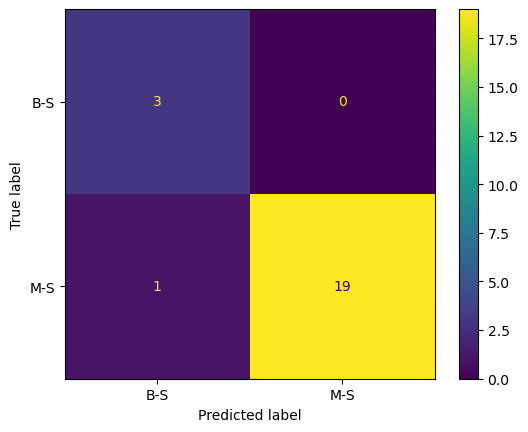

In [70]:
cm = confusion_matrix(y_train_rna, y_train_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Test

In [71]:
# Test

# Seperating out the features
X_test_rna = rna_df_test.drop(["SURGICAL"], axis=1)
# Seperating out the target
y_test_rna = rna_df_test[["SURGICAL"]]

y_test_rna_pred = fit_rf_rna.predict(X_test_rna)
cmat = mx.confusion_matrix(y_test_rna, y_test_rna_pred)

In [72]:
printPerformance(cmat)

Accuracy = 0.6667
Precision = 0.6000
Recall = 1.0000
Specificity = 0.3333
False positive rate = 0.6667
F1-score = 0.7500
Confusion matrix (%):
[[16.67 33.33]
 [ 0.   50.  ]]


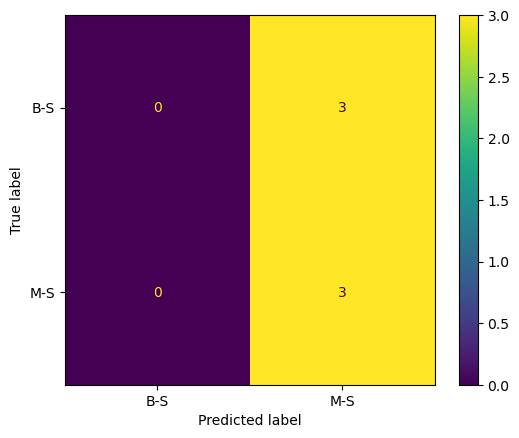

In [73]:
cm = confusion_matrix(y_test_img, y_test_img_pred, labels=fit_rf_img.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_img.classes_)
disp.plot()

### Plot the ROC Curve

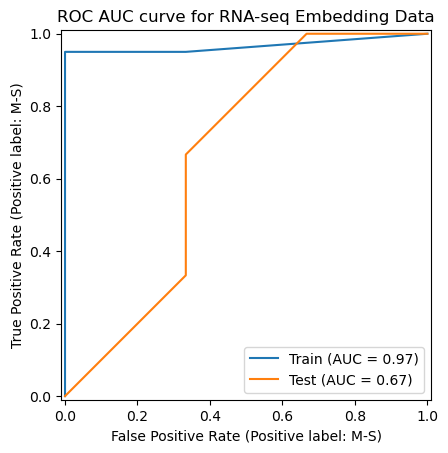

In [74]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_train_rna, y_train_rna, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_test_rna, y_test_rna, pos_label='M-S', ax = disp.ax_, name="Test")

# # Validation data
# disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_val_rna, y_val_rna, pos_label='M-S', ax = disp.ax_, name="Validation")

disp.ax_.set_title("ROC AUC curve for RNA-seq Embedding Data");